In [24]:
import polars as pl
from zipfile import ZipFile
import os
import matplotlib.pyplot as plt 
import skimage
from io import BytesIO

In [2]:
pathy = '~/vault/morphem/dataset/sampling/multi_channel_chammi_metadata.csv'

In [11]:

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_width_chars(-1)
pl.Config.set_tbl_cols(-1)
pl.Config.set_fmt_table_cell_list_len(-1)
pl.Config.set_fmt_str_lengths(1000)


polars.config.Config

In [19]:
pics = ZipFile(os.path.expanduser('~/scr/CHAMMI/chammi_train.zip'))

In [44]:
df = pl.read_csv(pathy)
images = list(df.filter(pl.col('storage.path').str.contains('/CP/')).group_by('imaging.multi_channel_id'))

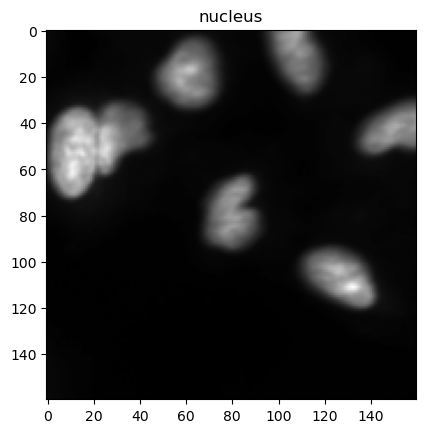

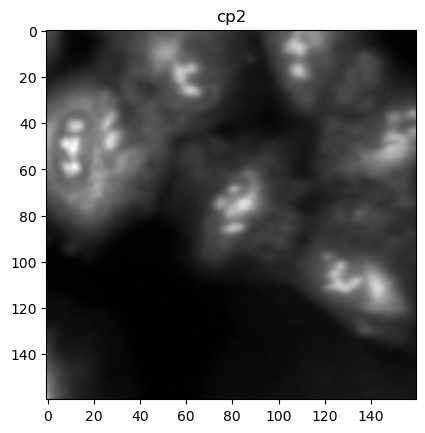

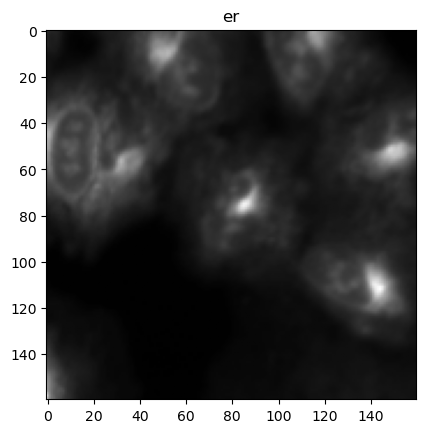

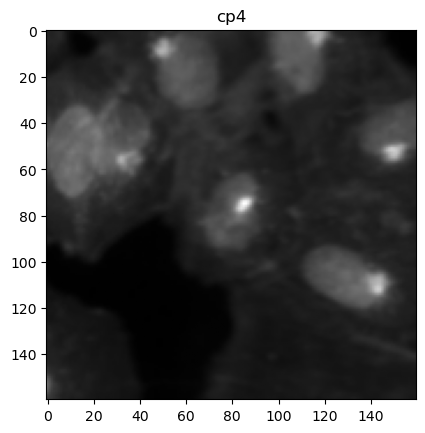

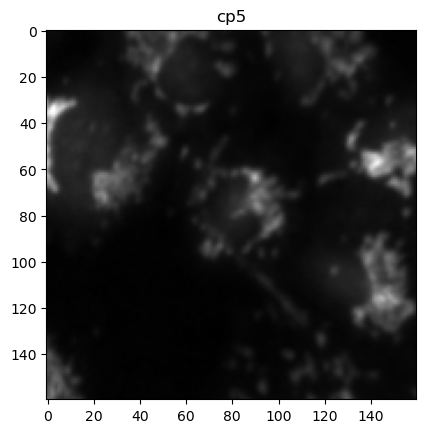

In [46]:
for row in images[3][1].iter_rows(named=True):
    pic = pics.read(row['storage.path'])
    np_pic = skimage.io.imread(BytesIO(pic))
    plt.imshow(np_pic, cmap='grey')
    plt.title(row['imaging.channel_type'])
    plt.show()